In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [18]:
df.isnull().sum()  
df.dropna(inplace=True) 

df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,0,159,5.0,90000.0
1,28.0,Female,1,17,3.0,65000.0
2,45.0,Male,2,130,15.0,150000.0
3,36.0,Female,0,101,7.0,60000.0
4,52.0,Male,1,22,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,0,131,8.0,85000.0
371,43.0,Male,1,30,19.0,170000.0
372,29.0,Female,0,70,2.0,40000.0
373,34.0,Male,0,137,7.0,90000.0


In [4]:
le_edu = LabelEncoder()
le_job = LabelEncoder()

df['Education Level'] = le_edu.fit_transform(df['Education Level'])
df['Job Title'] = le_job.fit_transform(df['Job Title'])

In [5]:
X = df[['Education Level', 'Job Title', 'Years of Experience']]
y = df['Salary']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

In [15]:
print("Linear Regression Performance:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Performance:
MAE: 11508.251879892658
RMSE: 15974.626271583707
R² Score: 0.8935641571948894


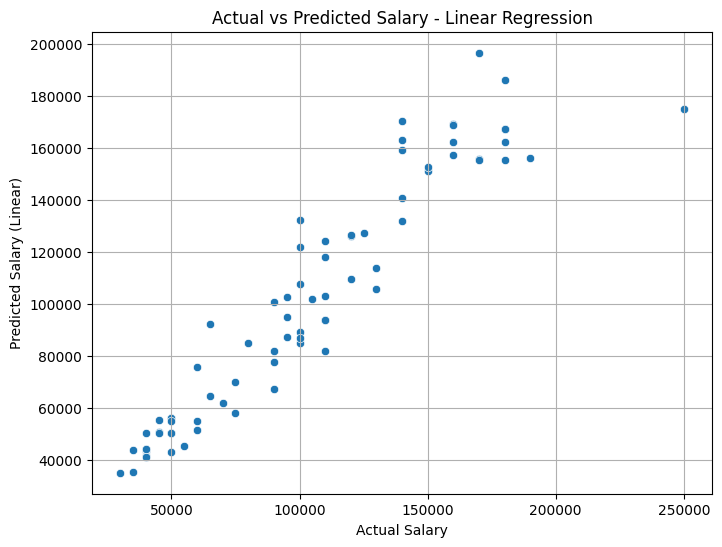

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=lr_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary (Linear)")
plt.title("Actual vs Predicted Salary - Linear Regression")
plt.grid(True)
plt.show()

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

In [16]:
print(" Random Forest Performance:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

 Random Forest Performance:
MAE: 9871.386238095238
RMSE: 13896.715309008367
R² Score: 0.919452732594658


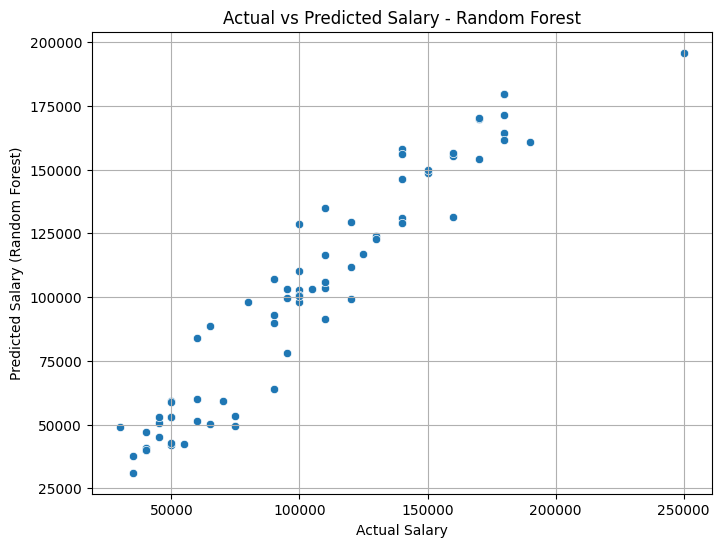

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=rf_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary (Random Forest)")
plt.title("Actual vs Predicted Salary - Random Forest")
plt.grid(True)
plt.show()

In [14]:
print(" Model Comparison Summary:")
print(f"Linear Regression R² Score:      {lr_r2:.4f}")
print(f"Random Forest Regression R² Score: {rf_r2:.4f}")


 Model Comparison Summary:
Linear Regression R² Score:      0.8936
Random Forest Regression R² Score: 0.9195
